In [46]:
import cv2 as cv
import numpy as np
import pandas as pd
import chess as ch
import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv('../Datasets/Images/3d_images_label/img_fen.csv')

In [48]:
def load_data(row, verbose=False):
    img_name = row['IMG']
    fen = row['FEN'].split()[0]

    board = ch.Board(fen)
    imagem = cv.imread(f"../Datasets/Images/3d_images/{img_name}.png", cv.IMREAD_COLOR)

    if verbose:
        print(f"[LOAD] Image: {img_name}")
    return img_name, imagem, board

In [49]:
def crop_image(imagem, verbose=False):
    center_x = imagem.shape[1] // 2
    center_y = imagem.shape[0] // 2

    imagem = imagem[
        center_y - 520:center_y + 450,
        center_x - 550:center_x + 550
    ]

    if verbose:
        print("[CROP] Image cropped to 1100x970 centered on the board")
    return imagem

In [50]:
def detect_edges(imagem, verbose=False):
    bordas = cv.Canny(imagem, 100, 150, apertureSize=3)
    if verbose:
        print("[CANNY] Edges detected")
    return bordas

In [51]:
def detect_lines(bordas, verbose=False):
    linhas = cv.HoughLines(bordas, 1, np.pi/180, 160)
    if verbose:
        print(f"[HOUGH] {len(linhas)} lines detected")
    return linhas

In [52]:
def group_lines(linhas, verbose=False):
    linhas_agrupadas = []

    for linha in linhas:
        rho, theta = linha[0]
        agrupada = False

        for l in linhas_agrupadas:
            rho_a, theta_a = l[0]

            if abs(rho - rho_a) < 30 and abs(theta - theta_a) < np.pi/18:
                agrupada = True
                break

        if not agrupada:
            linhas_agrupadas.append(linha)

    if verbose:
        print(f"[GROUP] {len(linhas_agrupadas)} grouped lines")
    return linhas_agrupadas

In [53]:
def filter_board_lines(linhas_agrupadas, verbose=False):
    min_rho = None

    for linha in linhas_agrupadas:
        rho, theta = linha[0]
        if 1 < theta < 3:
            if min_rho is None or rho < min_rho:
                min_rho = rho

    linhas_casas = [l for l in linhas_agrupadas if l[0][0] != min_rho]

    if verbose:
        print(f"[FILTER] {len(linhas_casas)} board lines")
    return linhas_casas

In [54]:
def compute_intersections(linhas_casas, verbose=False):
    linhas_pontos = []

    for linha in linhas_casas:
        rho, theta = linha[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho

        x1 = int(x0 + 10000 * (-b))
        y1 = int(y0 + 10000 * (a))
        x2 = int(x0 - 10000 * (-b))
        y2 = int(y0 - 10000 * (a))

        linhas_pontos.append([(x1, y1), (x2, y2), theta])

    pontos_por_linhas = []

    for i in range(len(linhas_pontos)):
        pontos = []

        for j in range(len(linhas_pontos)):
            x1, y1 = linhas_pontos[i][0]
            x2, y2 = linhas_pontos[i][1]
            x3, y3 = linhas_pontos[j][0]
            x4, y4 = linhas_pontos[j][1]

            det = (x1-x2)*(y3-y4) - (y1-y2)*(x3-x4)

            if det != 0:
                inter_x = int(((x1*y2-y1*x2)*(x3-x4)-(x1-x2)*(x3*y4-y3*x4)) / det)
                inter_y = int(((x1*y2-y1*x2)*(y3-y4)-(y1-y2)*(x3*y4-y3*x4)) / det)

                if 0 <= inter_x <= 1920 and 0 <= inter_y <= 1080:
                    if 1 < linhas_pontos[i][2] < 3:
                        pontos.append((inter_x, inter_y))

        if pontos:
            pontos.sort(key=lambda x: x[0])
            pontos_por_linhas.append(pontos)

    pontos_por_linhas.sort(key=lambda x: x[0][0])

    if verbose:
        print(f"[INTERSECTIONS] {len(pontos_por_linhas)} rows")
    return pontos_por_linhas

In [55]:
def build_squares(pontos_por_linhas, verbose=False):
    casas = []

    for i in range(len(pontos_por_linhas)-1):
        for j in range(len(pontos_por_linhas[i])-1):
            casas.append([
                pontos_por_linhas[i][j],
                pontos_por_linhas[i][j+1],
                pontos_por_linhas[i+1][j],
                pontos_por_linhas[i+1][j+1]
            ])

    if verbose:
        print(f"[SQUARES] {len(casas)} squares detected")
        
    return casas

In [56]:
def save_squares(casas, imagem, board, img_name, file, verbose=False):
    if len(casas) != 64:
        if verbose:
            print(f"[ERROR] Expected 64 squares, but found {len(casas)}. Skipping save.")
        return

    for i in range(64):
        p = casas[i]

        xs = [pt[0] for pt in p]
        ys = [pt[1] for pt in p]

        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        if y_min - 80 < 0:
            y_min = 80

        crop = imagem[y_min-90:y_max, x_min:x_max]

        piece = board.piece_at(i)
        symbol = piece.symbol() if piece else '0'

        file.write(f"{img_name}_{i},{symbol},{i}\n")
        cv.imwrite(f"../Datasets/Images/3d_images_squares/{img_name}_{i}.png", crop)

    if verbose:
        print("[SAVE] Done")

In [57]:
def show_image(img, title=""):
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [58]:
def process_row(index, file, plot=False, verbose=False):

    if verbose:
        print(f"\n===== Processing index {index} =====")

    row = df.iloc[index]

    img_name, imagem, board = load_data(row, verbose=verbose)

    if plot:
        show_image(imagem, "Original")

    imagem = crop_image(imagem, verbose=verbose)
    if plot:
        show_image(imagem, "Cropped")

    bordas = detect_edges(imagem, verbose=verbose)
    if plot:
        plt.figure(figsize=(6,6))
        plt.imshow(bordas, cmap='gray')
        plt.title("Canny")
        plt.axis("off")
        plt.show()

    linhas = detect_lines(bordas, verbose=verbose)

    linhas_agrupadas = group_lines(linhas, verbose=verbose)
    linhas_casas = filter_board_lines(linhas_agrupadas, verbose=verbose)

    # draw Hough lines
    if plot:
        img_hough = imagem.copy()
        for linha in linhas_casas:
            rho, theta = linha[0]
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a*rho, b*rho

            x1 = int(x0 + 10000*(-b))
            y1 = int(y0 + 10000*(a))
            x2 = int(x0 - 10000*(-b))
            y2 = int(y0 - 10000*(a))

            cv.line(img_hough, (x1,y1), (x2,y2), (0,0,255), 2)

        show_image(img_hough, "Hough Lines")

    pontos = compute_intersections(linhas_casas, verbose=verbose)

    # plot intersections
    if plot:
        img_pts = imagem.copy()

        for linha in pontos:
            for (x, y) in linha:
                cv.circle(img_pts, (x, y), 5, (255, 0, 0), -1)

        show_image(img_pts, "Intersections")

    casas = build_squares(pontos)
    
    if plot == False:
        save_squares(casas, imagem, board, img_name, file, verbose=verbose)


===== Processing index 42 =====
[LOAD] Image: i42


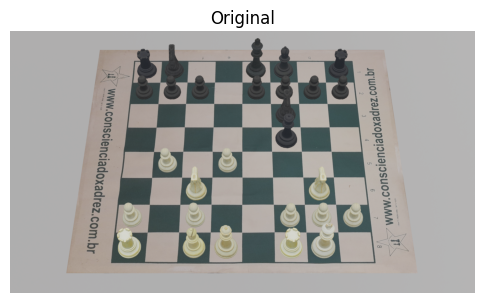

[CROP] Image cropped to 1100x970 centered on the board


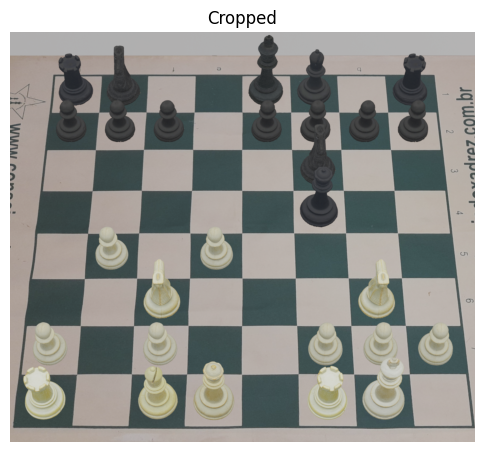

[CANNY] Edges detected


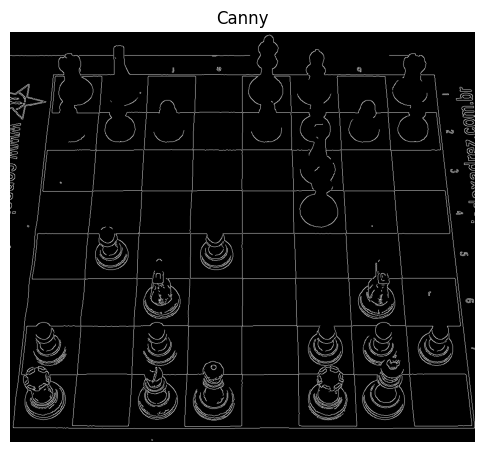

[HOUGH] 29 lines detected
[GROUP] 19 grouped lines
[FILTER] 18 board lines


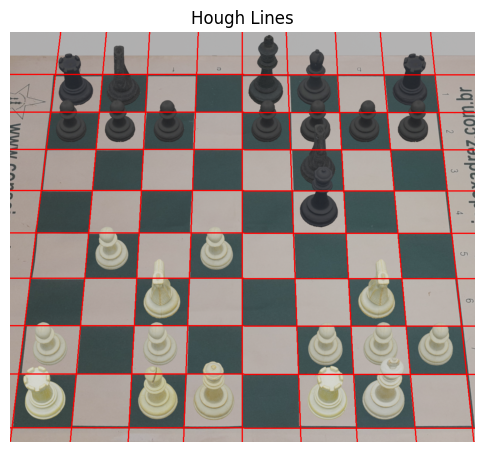

[INTERSECTIONS] 9 rows


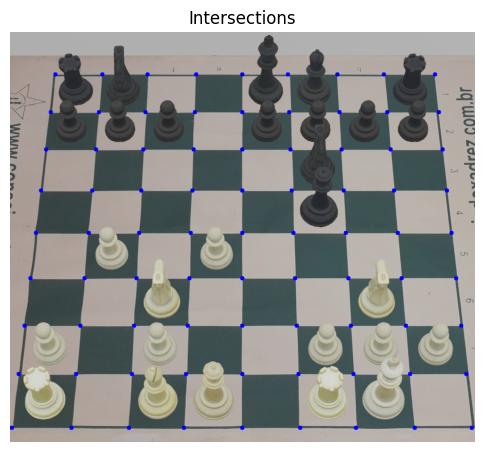

In [59]:
file = open("../Datasets/Images/3d_images_label/img_piece_square.csv", "w")
file.write("Image,Piece,Square\n")

process_row(42, file, plot=True, verbose=True)

file.close()

In [ ]:
file = open("../Datasets/Images/3d_images_label/img_piece_square.csv", "w")
file.write("Image,Piece,Square\n")

total = len(df)

for i in range(total):
    if i % 200 == 0:
        print(f"{(i/total)*100:.2f}% complete")

    try:
        process_row(i, file, plot=False, verbose=False)
    except Exception as e:
        with open("erros.txt", "a") as f:
            f.write(f"{i} error: {e}\n")

print("100% complete")
file.close()